# DSN–PRIDE Transfer Comparison

This notebook compares DSN-derived phase scintillation with PRIDE scintillation measurements across 2010–2014.

The workflow evaluates whether DSN Doppler-derived phase fluctuations recover the same heliospheric scintillation behaviour measured by PRIDE, and quantifies the transfer relation between the two systems across quiet and disturbed solar-wind conditions.

---

## Workflow

### SECTION 1 — Load DSN and PRIDE Multi-Year Data

1. Load DSN Doppler observations
2. Load PRIDE scintillation measurements
3. Identify common observing intervals
4. Construct DSN/PRIDE comparison bins
5. Build combined multi-year comparison tables

---

### SECTION 2 — DSN / PRIDE Validation Diagnostics

1. Compare DSN and PRIDE scintillation amplitudes
2. Compute cross-correlation statistics
3. Evaluate temporal overlap behaviour
4. Construct DSN/PRIDE validation summary plots

---

### SECTION 3 — Transfer Function Analysis

1. Fit DSN-to-PRIDE transfer relations
2. Evaluate SEP dependence
3. Evaluate quiet/disturbed-state behaviour
4. Compute yearly residual statistics
5. Assess transfer linearity

---

### SECTION 4 — Transfer Sensitivity Tests

1. Evaluate residual sensitivity
2. Test robustness of transfer slopes
3. Compare filtered and unfiltered fits
4. Assess fit stability across observing conditions

---

### SECTION 5 — Save Transfer Products

1. Save multi-year summary table
2. Save matched DSN/PRIDE comparison bins
3. Save SEP and state transfer fits
4. Save yearly residual summaries
5. Save sensitivity diagnostics

---

### SECTION 6 — Final Interpretation

1. Summarise DSN/PRIDE agreement
2. Evaluate transfer linearity
3. Assess SEP dependence
4. Identify systematic DSN suppression regimes

---

## Outputs

This notebook produces:

- `dsn_pride_multiyear_summary.csv`
- `dsn_pride_matched_bins_qc.csv`
- `dsn_pride_sep_transfer_fit.csv`
- `dsn_pride_state_transfer_fit.csv`
- `dsn_pride_year_residual_summary.csv`
- `dsn_pride_fit_sensitivity.csv`

These outputs quantify the statistical transfer relation between DSN-derived phase scintillation and PRIDE scintillation measurements.

In [1]:
# ============================================================
# SECTION 0 — Setup
# ============================================================

%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))



In [2]:
# ============================================================
# Configuration
# ============================================================

YEARS = [2010, 2011, 2012, 2013, 2014]

debug = True
save_files = False

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "pride_transfer"

from src.pride_comparison_utils import (
    load_dsn_doppler_file,
    load_pride_scint_file,
    get_common_days,
    build_dsn_pride_binned_comparison,
    build_daily_dsn_pride_summary,
    compute_signal_correlations,
    compute_xcorr_summary,
    compute_sigma_phi_binned,
)

from src.pride_transfer_analysis import (
    run_multiyear_dsn_pride_analysis,
    run_transfer_analysis,
    plot_long_term_overlap,
    plot_validation_summary,
    plot_transfer_summary,
    plot_state_transfer,
    plot_residual_summary,
    plot_year_residuals,
    plot_fit_sensitivity,
)
from src.io_utils import remove_known_bad_tracking_intervals
if debug:
    print("PROJECT_ROOT:", PROJECT_ROOT)
    print("OUTPUT_DIR:", OUTPUT_DIR)
    print("YEARS:", YEARS)

PROJECT_ROOT: /mnt/data/jhub/16-VenusExpres/dsn_multi_year
OUTPUT_DIR: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/pride_transfer
YEARS: [2010, 2011, 2012, 2013, 2014]


# SECTION 1 — Load DSN and PRIDE Multi-Year Data

In [3]:
YEAR_GROUPS = [[year] for year in YEARS]

partial_results = []

for year_group in YEAR_GROUPS:

    print("Running:", year_group)

    r = run_multiyear_dsn_pride_analysis(
        project_root=PROJECT_ROOT,
        years=year_group,
        load_dsn_doppler_file=load_dsn_doppler_file,
        load_pride_scint_file=load_pride_scint_file,
        get_common_days=get_common_days,
        build_dsn_pride_binned_comparison=build_dsn_pride_binned_comparison,
        build_daily_dsn_pride_summary=build_daily_dsn_pride_summary,
        compute_signal_correlations=compute_signal_correlations,
        compute_xcorr_summary=compute_xcorr_summary,
        compute_sigma_phi_binned=None,
    )

    partial_results.append(r)

results = {
    "multi_summary_df": pd.concat(
        [r["multi_summary_df"] for r in partial_results],
        ignore_index=True,
    ),

    "all_qc_df": pd.concat(
        [r["all_qc_df"] for r in partial_results],
        ignore_index=False,
    ),

    "all_daily_df": pd.concat(
        [r["all_daily_df"] for r in partial_results],
        ignore_index=False,
    ),

    "all_xcorr_df": pd.concat(
        [r["all_xcorr_df"] for r in partial_results],
        ignore_index=True,
    ),

    "dsn_all_df": pd.DataFrame(),
}

display(results["multi_summary_df"])

Running: [2010]

========== YEAR 2010 ==========
DSN rows: 868313
PRIDE rows: 8
Common observing days: 1
2010 Horizons: /mnt/data/jhub/16-VenusExpres/Scint_analysis/vex_2010.txt
2010 missing elongation: 0
QC bins: 7
Daily Pearson r: nan
Median DSN/PRIDE ratio: 0.6226667019727602
Running: [2011]

========== YEAR 2011 ==========
DSN rows: 805358
PRIDE rows: 35
Common observing days: 6
2011 Horizons: /mnt/data/jhub/16-VenusExpres/Scint_analysis/vex_2011.txt
2011 missing elongation: 0
QC bins: 27
Daily Pearson r: 0.879438458841961
Median DSN/PRIDE ratio: 0.9171679060719268
Running: [2012]

========== YEAR 2012 ==========
DSN rows: 928601
PRIDE rows: 62
Common observing days: 15
2012 Horizons: /mnt/data/jhub/16-VenusExpres/Scint_analysis/vex_2012.txt
2012 missing elongation: 0
QC bins: 41
Daily Pearson r: 0.2518079058449985
Median DSN/PRIDE ratio: 0.813754916525862
Running: [2013]

========== YEAR 2013 ==========
DSN rows: 792142
PRIDE rows: 55
Common observing days: 10
2013 Horizons: /mnt/

,year,common_days,raw_bins,qc_bins,daily_rows,window_pearson_r,window_pearson_p,daily_pearson_r,daily_pearson_p,window_spearman_r,...,ratio_q75,frac_within_factor_2,frac_dsn_stronger,frac_dsn_weaker,valid_xcorr_days,median_best_lag_min,median_best_corr,median_zero_lag_corr,frac_near_zero_lag,frac_positive_zero_lag_corr
0,2010,1,7,7,1,-0.195584,6.742799e-01,NaN,NaN,-0.285714,...,0.725779,0.571429,0.000000,1.000000,1,-60.0,0.852217,-0.195584,0.00000,0.000000
1,2011,6,27,27,6,0.641216,3.132494e-04,0.879438,2.092644e-02,0.729354,...,1.162608,0.962963,0.407407,0.592593,4,0.0,0.570278,0.346776,0.50000,0.750000
2,2012,15,41,41,11,0.198168,2.142315e-01,0.251808,4.550912e-01,0.360413,...,1.126589,0.780488,0.317073,0.682927,6,0.0,0.733859,0.664188,1.00000,1.000000
3,2013,10,35,35,9,0.968928,1.352848e-21,0.989484,3.886212e-07,0.831373,...,1.290465,0.971429,0.657143,0.342857,4,-10.0,0.556325,0.366530,0.75000,0.750000
4,2014,56,439,406,53,0.578136,1.394202e-37,0.685655,1.470873e-08,0.556049,...,1.245986,0.871921,0.475369,0.524631,46,0.0,0.682812,0.541224,0.76087,0.847826


In [4]:
if debug:

    print("Matched QC rows:", len(results["all_qc_df"]))
    print("Daily rows:", len(results["all_daily_df"]))
    print("Cross-correlation rows:", len(results["all_xcorr_df"]))

    display(results["all_qc_df"].head())
    display(results["all_qc_df"].tail())

Matched QC rows: 516
Daily rows: 80
Cross-correlation rows: 80


,dsn_sigma_phi_rad,n_dsn_samples,pride_scint_rad,day,elongation_deg,year,dsn_pride_ratio,log10_dsn_pride_ratio
timestamp,,,,,,,,
2010-08-30 12:20:00,0.199743,120,0.260,2010-08-30,45.5735,2010,0.768243,-0.114502
2010-08-30 12:40:00,0.207529,119,0.221,2010-08-30,45.5735,2010,0.939046,-0.027313
2010-08-30 13:00:00,0.091904,120,0.253,2010-08-30,45.5735,2010,0.363256,-0.439788
2010-08-30 13:20:00,0.119711,120,0.336,2010-08-30,45.5735,2010,0.356282,-0.448206
2010-08-30 13:40:00,0.125801,120,0.287,2010-08-30,45.5735,2010,0.438330,-0.358199


,dsn_sigma_phi_rad,n_dsn_samples,pride_scint_rad,day,elongation_deg,year,dsn_pride_ratio,log10_dsn_pride_ratio
timestamp,,,,,,,,
2014-06-07 09:00:00,0.410129,120,0.268,2014-06-07,35.7736,2014,1.530334,0.184786
2014-06-07 09:20:00,0.339243,120,0.186,2014-06-07,35.7736,2014,1.823885,0.260997
2014-06-07 09:40:00,0.346611,120,0.171,2014-06-07,35.7736,2014,2.026965,0.306846
2014-06-07 10:00:00,0.322551,120,0.170,2014-06-07,35.7736,2014,1.897359,0.278149
2014-06-07 10:20:00,0.326006,120,0.148,2014-06-07,35.7736,2014,2.202746,0.342964


In [13]:
# ============================================================
# SECTION — Build all DSN-only phase scintillation bins
# ============================================================

from src.pride_comparison_utils import compute_sigma_phi_binned

all_dsn_bins = []

DATA_ROOT = PROJECT_ROOT.parent

for yr in YEARS:

    print(f"\n========== DSN YEAR {yr} ==========")

    DSN_FILE = DATA_ROOT / "dataByYear" / f"data_{yr}.txt"

    if not DSN_FILE.exists():
        print("Missing:", DSN_FILE)
        continue

    dsn_df_year = load_dsn_doppler_file(DSN_FILE)

    dsn_df_year = remove_known_bad_tracking_intervals(
        df=dsn_df_year.reset_index(),
        year=yr,
        time_col="UTC_time",
        verbose=True,
    )
    
    dsn_df_year = dsn_df_year.set_index("UTC_time").sort_index()

    dsn_df_year = dsn_df_year[
        dsn_df_year["doppler"].abs() < 0.20
    ].copy()
    
    dsn_bins_year = compute_sigma_phi_binned(
        dsn_df_year,
        bin_freq="20min",
        f_low_hz=3e-3,
        f_high_hz=0.1,
        detrend_poly_order=4,
        min_samples=16,
    )

    dsn_bins_year = dsn_bins_year.reset_index(names="utc_time")
    dsn_bins_year["year"] = yr

    print("DSN bins:", len(dsn_bins_year))

    all_dsn_bins.append(dsn_bins_year)

dsn_all_df = pd.concat(all_dsn_bins, ignore_index=True)
dsn_all_df["utc_time"] = pd.to_datetime(dsn_all_df["utc_time"])
dsn_all_df = dsn_all_df.sort_values("utc_time").reset_index(drop=True)

display(dsn_all_df.head())
print("Total DSN bins:", len(dsn_all_df))


========== DSN YEAR 2010 ==========
[QC] No known bad tracking intervals for 2010
DSN bins: 7508

========== DSN YEAR 2011 ==========
[QC] No known bad tracking intervals for 2011
DSN bins: 6967

========== DSN YEAR 2012 ==========
[QC] No known bad tracking intervals for 2012
DSN bins: 8002

========== DSN YEAR 2013 ==========
[QC] No known bad tracking intervals for 2013
DSN bins: 6844

========== DSN YEAR 2014 ==========
[QC] Removing 2014 bad tracking interval 2014-05-20 → 2014-05-31 | rows removed: 43010
[QC] Rows after removal: 368288
DSN bins: 2835


,utc_time,dsn_sigma_phi_rad,n_dsn_samples,year
0,2010-01-01 09:20:00,0.882317,16,2010
1,2010-01-01 09:40:00,4.067152,120,2010
2,2010-01-01 10:00:00,6.683517,120,2010
3,2010-01-01 10:20:00,4.587380,120,2010
4,2010-01-01 10:40:00,2.035611,41,2010


Total DSN bins: 32156


In [14]:
# ============================================================
# BUILD COMBINED PRIDE TABLE
# ============================================================

all_pride = []

DATA_ROOT = PROJECT_ROOT.parent

for yr in YEARS:

    PRIDE_FILE = DATA_ROOT / "scintdataByYear" / f"scint_{yr}.txt"

    if not PRIDE_FILE.exists():
        print("Missing:", PRIDE_FILE)
        continue

    pride_df = load_pride_scint_file(PRIDE_FILE)

    pride_df = pride_df.reset_index(names="utc_time")

    pride_df["year"] = yr

    all_pride.append(pride_df)

all_pride_df = pd.concat(all_pride, ignore_index=True)

all_pride_df["utc_time"] = pd.to_datetime(all_pride_df["utc_time"])

display(all_pride_df.head())

print("Total PRIDE rows:", len(all_pride_df))

,utc_time,Scint_rad,Slope,Slope_err,PeakSPD,TEC_Down,TEC_Up,TEC_Total,Dnoise,year
0,2010-08-30 12:20:00,0.260,-2.846,0.11,8.0,20.4,21.3,101.2,3.21,2010
1,2010-08-30 12:40:00,0.221,-2.846,0.11,8.0,19.6,20.3,101.2,2.49,2010
2,2010-08-30 13:00:00,0.253,-2.846,0.11,8.0,19.0,19.5,101.2,1.80,2010
3,2010-08-30 13:30:00,0.336,-2.846,0.11,8.0,18.4,18.6,101.2,2.41,2010
4,2010-08-30 13:40:00,0.287,-2.846,0.11,8.0,18.5,18.4,101.2,2.75,2010


Total PRIDE rows: 1262


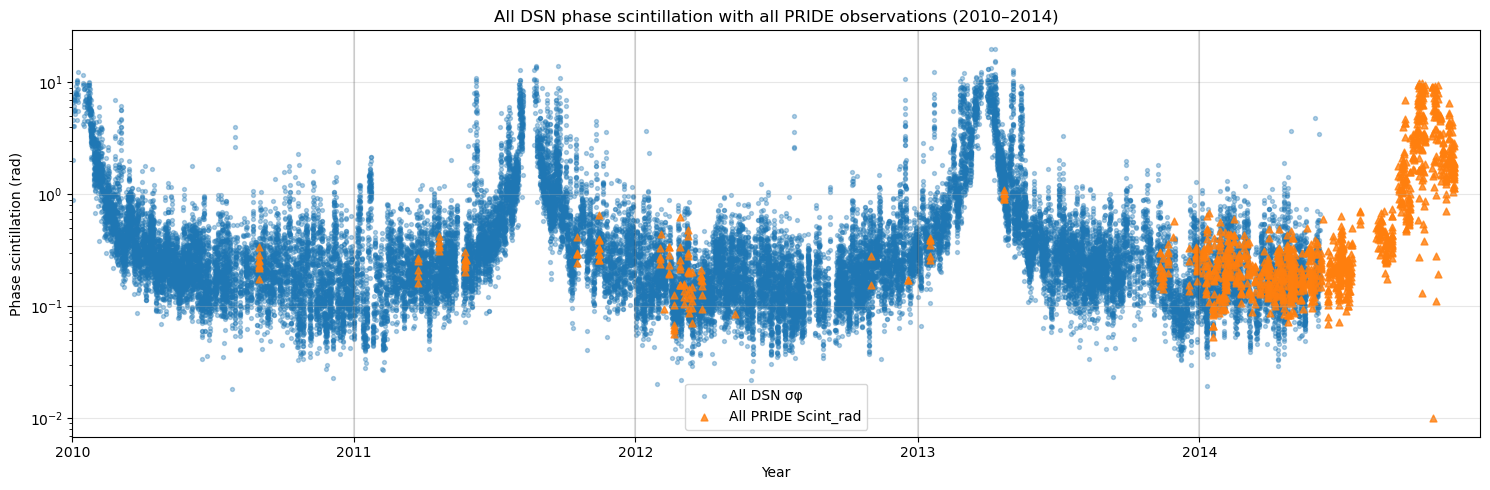

In [15]:
import matplotlib.dates as mdates
# ============================================================
# PLOT — All DSN bins with ALL PRIDE data
# ============================================================

fig, ax = plt.subplots(figsize=(15, 5))

# All DSN bins, not just PRIDE-matched windows
ax.scatter(
    dsn_all_df["utc_time"],
    dsn_all_df["dsn_sigma_phi_rad"],
    s=8,
    alpha=0.35,
    label="All DSN σφ",
)

# All PRIDE points
ax.scatter(
    all_pride_df["utc_time"],
    all_pride_df["Scint_rad"],
    s=24,
    alpha=0.8,
    marker="^",
    label="All PRIDE Scint_rad",
)

ax.set_xlim(pd.Timestamp("2010-01-01"), pd.Timestamp("2014-12-31"))

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

for yr in range(2010, 2015):
    ax.axvline(pd.Timestamp(f"{yr}-01-01"), color="black", alpha=0.12)

ax.set_yscale("log")
ax.set_xlabel("Year")
ax.set_ylabel("Phase scintillation (rad)")
ax.set_title("All DSN phase scintillation with all PRIDE observations (2010–2014)")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# SECTION 2 — DSN / PRIDE Validation Diagnostics

In [26]:
plot_long_term_overlap(
    results["dsn_all_df"],
    results["all_qc_df"],
)

No DSN-only dataframe available. Skipping long-term overlap plot.


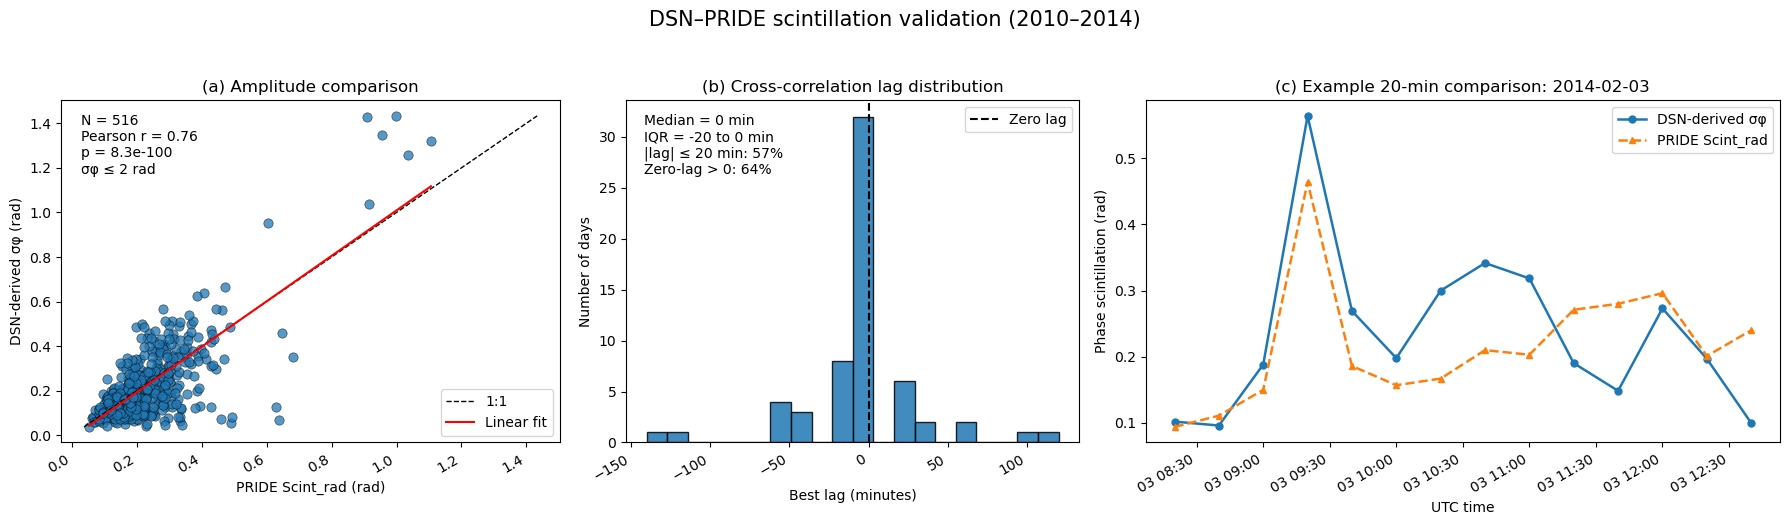

In [19]:
figure_df = results["all_qc_df"].copy()

figure_df = figure_df[
    (figure_df["dsn_sigma_phi_rad"] > 0)
    & (figure_df["dsn_sigma_phi_rad"] <= 2.0)
    & (figure_df["pride_scint_rad"] > 0)
].copy()

plot_validation_summary(
    figure_df,
    results["all_xcorr_df"],
    year="2010–2014",
)

# SECTION 3 — Transfer Function Analysis

In [20]:
fits = run_transfer_analysis(
    results["all_qc_df"],
)

chi_summary = {
    k: v
    for k, v in fits["chi_fit"].items()
    if k != "fit_df"
}

display(pd.DataFrame([chi_summary]))
display(fits["sep_fit"])
display(fits["state_fit"])
display(fits["year_residual_summary"])

,intercept,alpha,intercept_err,alpha_err,chi2,dof,reduced_chi2,observed_scatter_dex,measurement_scatter_dex,intrinsic_scatter_dex,intrinsic_scatter_factor
0,-0.18433,0.801366,0.013846,0.019168,2844.465081,514,5.533979,0.203934,0.086859,0.184512,1.529368


,sep_bin,n,median_sep,alpha,alpha_err,intercept,r,p,scatter_dex,scatter_factor,median_ratio
0,5–10,38,6.1127,1.066191,0.234558,-0.175888,0.603864,5.969445e-05,0.378616,2.391198,0.974041
1,10–20,29,14.8687,0.949194,0.097685,-0.037876,0.881832,2.619716e-10,0.120558,1.319952,1.011533
2,20–40,186,35.7736,0.873524,0.063715,-0.082090,0.710863,6.198227e-30,0.153677,1.424548,1.033266
3,40–90,263,44.8604,0.678024,0.068791,-0.300488,0.520814,1.093681e-19,0.190459,1.550454,0.912849


,state,n,alpha,alpha_err,intercept,r,p,scatter_dex,scatter_factor,median_ratio
0,disturbed,130,0.983653,0.187675,-0.112238,0.420350,6.388727e-07,0.271433,1.868240,0.927025
1,quiet/moderate,386,0.798685,0.064896,-0.183601,0.531853,1.432234e-29,0.174838,1.495676,0.986615


,year,n,median_residual,scatter_dex,median_factor
0,2010,7,-0.146342,0.154638,0.713934
1,2011,27,0.065328,0.138594,1.162327
2,2012,41,-0.071829,0.206312,0.847561
3,2013,35,0.099159,0.148166,1.256490
4,2014,406,0.029978,0.206210,1.071465


# SECTION 4 — Transfer Sensitivity Tests

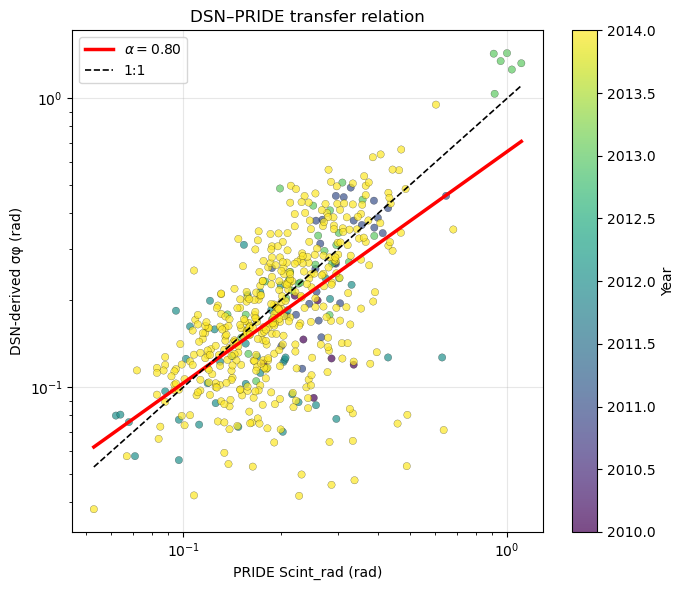

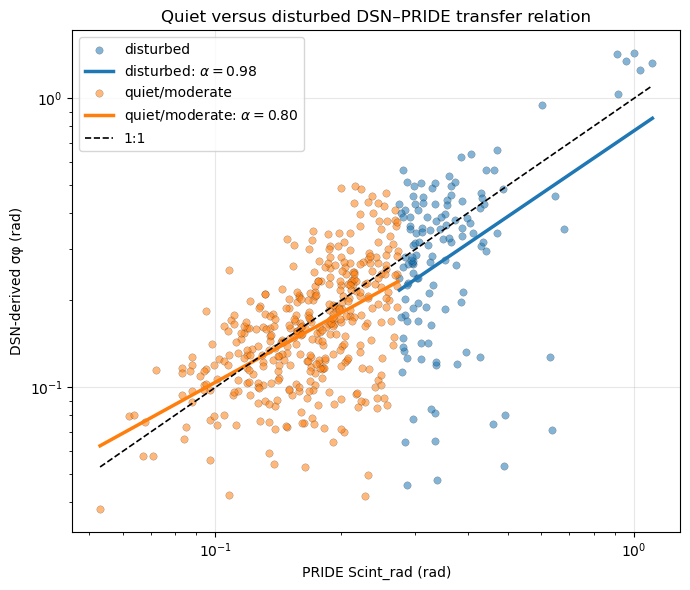

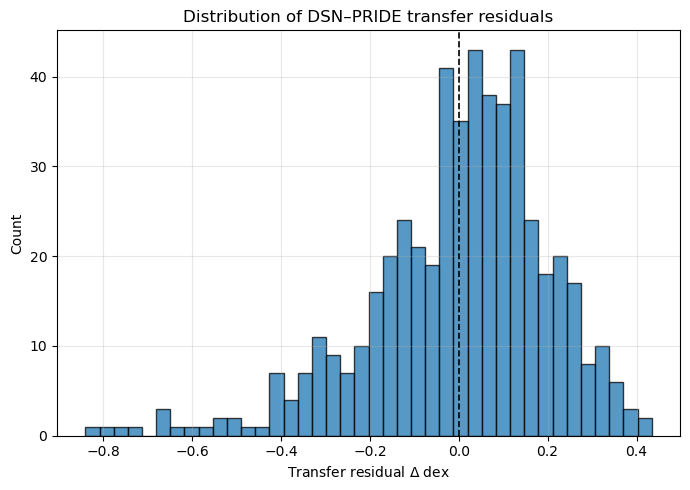

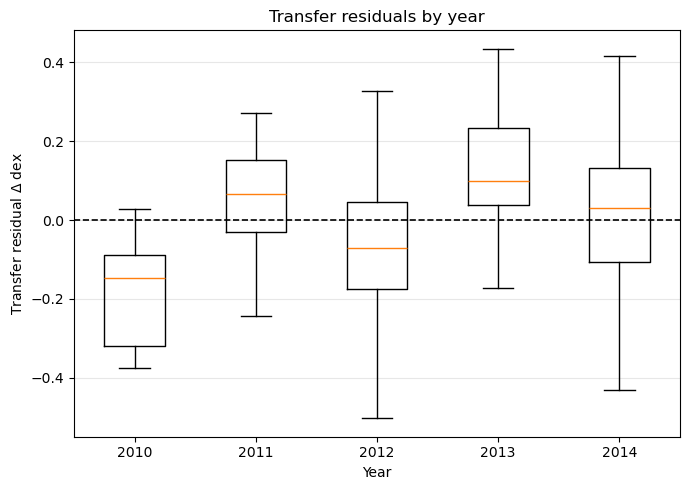

In [21]:
plot_transfer_summary(
    results,
    fits,
)

plot_state_transfer(
    fits,
)

plot_residual_summary(
    fits,
)

plot_year_residuals(
    fits,
)

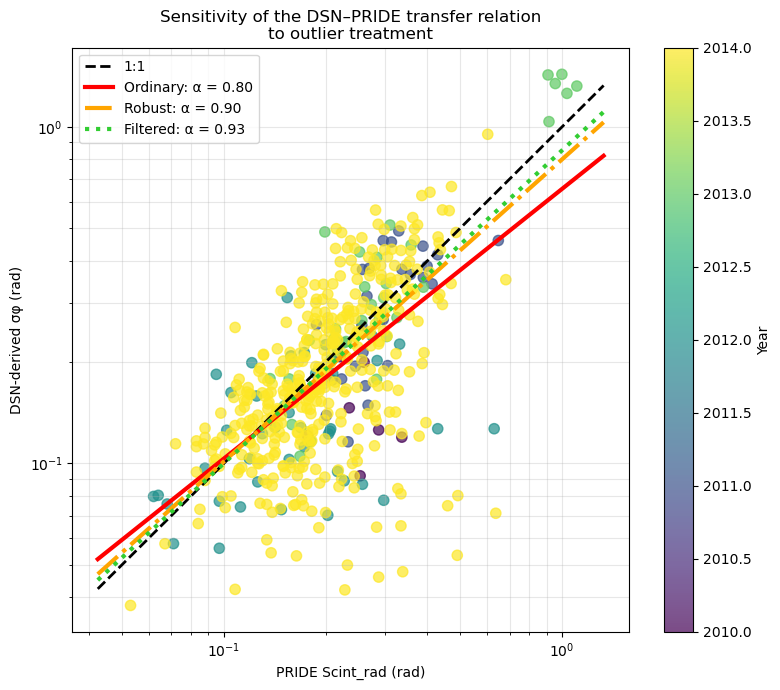

,fit_type,alpha,intercept
0,ordinary,0.801366,-0.184330
1,robust,0.897775,-0.096609
2,filtered,0.930158,-0.069820


In [22]:
sensitivity_df = plot_fit_sensitivity(
    fits,
)

display(sensitivity_df)

# SECTION 5 — Save Transfer Products

In [23]:
if save_files:

    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    results["multi_summary_df"].to_csv(
        OUTPUT_DIR / "dsn_pride_multiyear_summary.csv",
        index=False,
    )

    results["all_qc_df"].to_csv(
        OUTPUT_DIR / "dsn_pride_matched_bins_qc.csv",
        index=True,
    )

    fits["sep_fit"].to_csv(
        OUTPUT_DIR / "dsn_pride_sep_transfer_fit.csv",
        index=False,
    )

    fits["state_fit"].to_csv(
        OUTPUT_DIR / "dsn_pride_state_transfer_fit.csv",
        index=False,
    )

    fits["year_residual_summary"].to_csv(
        OUTPUT_DIR / "dsn_pride_year_residual_summary.csv",
        index=False,
    )

    sensitivity_df.to_csv(
        OUTPUT_DIR / "dsn_pride_fit_sensitivity.csv",
        index=False,
    )

    print("Saved outputs to:", OUTPUT_DIR)